In [61]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import json

In [62]:
with open(r'D:\PythonFiles\FPL_2024_25\FPL_2024-25\Data\bootstrap_data_2024_25.json', "r") as f:
    data = json.load(f)

df = pd.DataFrame(data['elements'])

In [63]:
df.columns.to_list()

['can_transact',
 'can_select',
 'chance_of_playing_next_round',
 'chance_of_playing_this_round',
 'code',
 'cost_change_event',
 'cost_change_event_fall',
 'cost_change_start',
 'cost_change_start_fall',
 'dreamteam_count',
 'element_type',
 'ep_next',
 'ep_this',
 'event_points',
 'first_name',
 'form',
 'id',
 'in_dreamteam',
 'news',
 'news_added',
 'now_cost',
 'photo',
 'points_per_game',
 'removed',
 'second_name',
 'selected_by_percent',
 'special',
 'squad_number',
 'status',
 'team',
 'team_code',
 'total_points',
 'transfers_in',
 'transfers_in_event',
 'transfers_out',
 'transfers_out_event',
 'value_form',
 'value_season',
 'web_name',
 'region',
 'team_join_date',
 'birth_date',
 'has_temporary_code',
 'opta_code',
 'minutes',
 'goals_scored',
 'assists',
 'clean_sheets',
 'goals_conceded',
 'own_goals',
 'penalties_saved',
 'penalties_missed',
 'yellow_cards',
 'red_cards',
 'saves',
 'bonus',
 'bps',
 'influence',
 'creativity',
 'threat',
 'ict_index',
 'starts',
 'exp

In [64]:
df = df[['code','id','element_type','team','total_points','web_name','birth_date','minutes',
 'goals_scored',
 'assists',
 'clean_sheets',
 'goals_conceded',
 'own_goals',
 'penalties_saved',
 'penalties_missed',
 'yellow_cards',
 'red_cards',
 'saves',
 'bonus',
 'bps','ict_index',
 'starts',
 'expected_goals',
 'expected_assists',
 'expected_goal_involvements',
 'expected_goals_conceded',]]

In [65]:
df = df[df['element_type'] != 5]

In [66]:
df.sample(10)

,code,id,element_type,team,total_points,web_name,birth_date,minutes,goals_scored,assists,...,red_cards,saves,bonus,bps,ict_index,starts,expected_goals,expected_assists,expected_goal_involvements,expected_goals_conceded
361,573062,605,3,9,2,Godo,2003-03-14,21,0,0,...,0,0,0,4,3.0,0,0.00,0.07,0.07,0.15
708,165153,509,3,18,34,Werner,1996-03-06,504,0,3,...,0,0,2,120,37.1,4,1.04,1.55,2.59,11.41
746,103192,532,2,19,0,Zouma,None,0,0,0,...,0,0,0,0,0.0,0,0.00,0.00,0.00,0.00
155,220695,674,3,4,8,Maghoma,2001-05-08,112,0,0,...,0,0,0,32,5.4,0,0.12,0.04,0.16,1.89
275,209400,205,3,7,45,Kamada,1996-08-05,1545,0,0,...,1,0,0,246,68.2,15,1.12,1.55,2.67,25.74
94,223911,72,2,3,0,Mepham,None,0,0,0,...,0,0,0,0,0.0,0,0.00,0.00,0.00,0.00
379,222625,272,4,10,46,Hirst,1999-02-15,645,3,1,...,0,0,3,157,41.2,5,2.14,0.24,2.38,15.41
693,200826,493,3,18,0,Lo Celso,None,0,0,0,...,0,0,0,0,0.0,0,0.00,0.00,0.00,0.00
17,223723,22,2,1,1,Tomiyasu,1998-11-05,6,0,0,...,0,0,0,2,1.0,0,0.18,0.00,0.18,0.04
416,549640,292,3,11,1,Golding,2006-05-23,1,0,0,...,0,0,0,3,0.0,0,0.00,0.00,0.00,0.00


In [67]:
rename_element_type = {4:"Forward",
 3:'Midfielder',
 2: 'Defender',
 1:'Goalkeeper'}

In [68]:
df['element_type'] = df['element_type'].replace(rename_element_type)

In [69]:
df.sort_values(by='code')

,code,id,element_type,team,total_points,web_name,birth_date,minutes,goals_scored,assists,...,red_cards,saves,bonus,bps,ict_index,starts,expected_goals,expected_assists,expected_goal_involvements,expected_goals_conceded
180,15157,134,Midfielder,5,6,Milner,1986-01-04,170,0,0,...,0,0,0,27,10.7,3,0.16,0.15,0.31,1.98
486,17601,344,Goalkeeper,13,0,Carson,1985-09-03,0,0,0,...,0,0,0,0,0.0,0,0.00,0.00,0.00,0.00
317,17761,236,Defender,8,105,Tarkowski,1992-11-19,2922,1,1,...,0,0,8,468,126.9,33,1.32,2.33,3.65,39.30
319,18892,238,Defender,8,98,Young,1985-07-09,1864,1,4,...,1,0,9,354,86.8,19,0.27,2.87,3.14,26.17
587,19236,414,Goalkeeper,15,0,Ruddy,1986-10-24,0,0,0,...,0,0,0,0,0.0,0,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,630664,797,Midfielder,11,4,Jake Evans,2008-06-04,21,0,0,...,0,0,0,13,0.3,0,0.00,0.00,0.00,0.20
113,632822,702,Defender,3,0,Harris,2004-12-27,0,0,0,...,0,0,0,0,0.0,0,0.00,0.00,0.00,0.00
786,641221,561,Defender,20,2,Pedro Lima,2006-07-01,69,0,0,...,0,0,0,9,6.9,1,0.06,0.10,0.16,0.77
803,647671,784,Forward,20,1,Mané,2007-09-16,1,0,0,...,0,0,0,3,0.0,0,0.00,0.00,0.00,0.00


# Simple Linear Regression 
## Using single feature and target column

In [77]:
df_subset = df[['web_name','element_type','goals_scored','total_points']]

In [78]:
df_subset.sort_values(by='goals_scored',ascending=False)

,web_name,element_type,goals_scored,total_points
464,M.Salah,Midfielder,29,344
574,Isak,Forward,23,211
493,Haaland,Forward,22,181
624,Wood,Forward,20,200
135,Mbeumo,Midfielder,20,236
...,...,...,...,...
768,Dawson,Defender,0,17
766,Cundle,Midfielder,0,0
765,Chiwome,Forward,0,0
764,Chirewa,Midfielder,0,0


<Axes: xlabel='total_points', ylabel='goals_scored'>

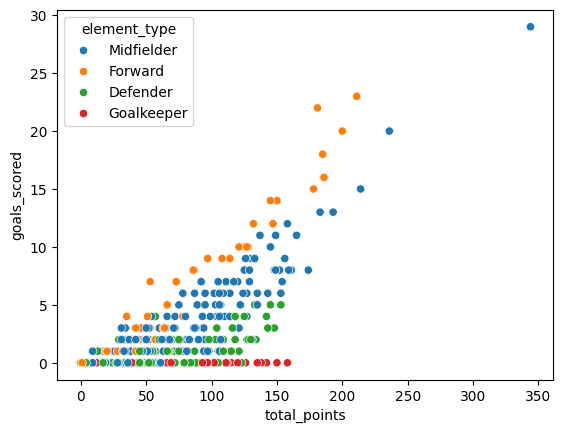

In [79]:
sns.scatterplot(data=df_subset,x='total_points',y='goals_scored',hue='element_type')

- Target Variable = Points
- Feature Variable = Goals scored by forwards

<Axes: xlabel='total_points', ylabel='goals_scored'>

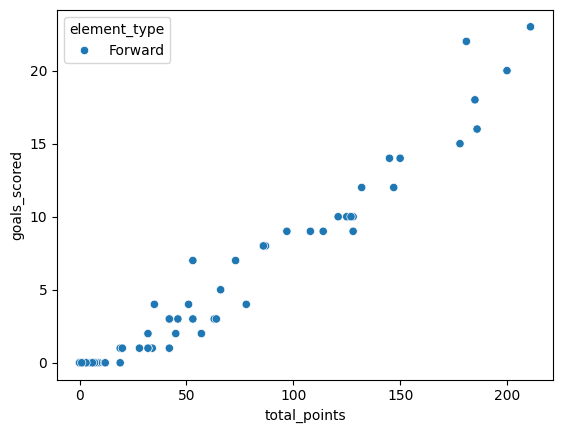

In [81]:
sns.scatterplot(data=df_subset[df_subset['element_type'] == 'Forward'],x='total_points',y='goals_scored',hue='element_type')

In [ ]:
X = df[df_subset]